In [1]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict

c:\Users\Muhammad Hashir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [14]:
class CricketState(TypedDict):

    runs : int
    wickets : int
    balls : int
    fours : int 
    sixes : int 

    strike_rate : float 
    balls_per_boundry : float
    boundry_percentage : float
    summary : str

In [23]:
def calculate_str(state: CricketState):

    
    print("calculating strike rate")
    state["strike_rate"] = (state["runs"]/(state["balls"]))*100
    return {
        "strike_rate": state["strike_rate"] }

In [24]:
def calcualte_bpb(state : CricketState):

    
    print("calculating balls per boundry")
    state["balls_per_boundry"] = state["balls"]/((state["fours"]*4)+(state["sixes"]*6))
    return {"balls_per_boundry": state["balls_per_boundry"]}

In [25]:
def calculate_boundryper(state: CricketState):
    
    print("calculating boundry percentage")
    state["boundry_percentage"] = ((state["fours"]*4)+(state["sixes"]*6))/state["runs"]
    return {"boundry_percentage" :state["boundry_percentage"]}

    

In [26]:
def calculate_summary(state: CricketState):

    
    print("calculating summary")
    state["summary"] = f'''Strike Rate : {state["strike_rate"]}
    Balls Per Boundry : {state["balls_per_boundry"]}
    Boundry Percentage : {state["boundry_percentage"]}'''

    return {
        "summary": state["summary"]}

In [27]:
graph = StateGraph(CricketState)

graph.add_node("calculate_str", calculate_str)
graph.add_node("calcualte_bpb", calcualte_bpb)
graph.add_node("calculate_boundryper", calculate_boundryper)
graph.add_node("calculate_summary", calculate_summary)

graph.add_edge(START, "calculate_str")
graph.add_edge(START, "calcualte_bpb")
graph.add_edge(START, "calculate_boundryper")

graph.add_edge("calculate_str", "calculate_summary")
graph.add_edge("calcualte_bpb", "calculate_summary")
graph.add_edge("calculate_boundryper", "calculate_summary")

graph.add_edge("calculate_summary", END)

In [28]:
workflow = graph.compile()

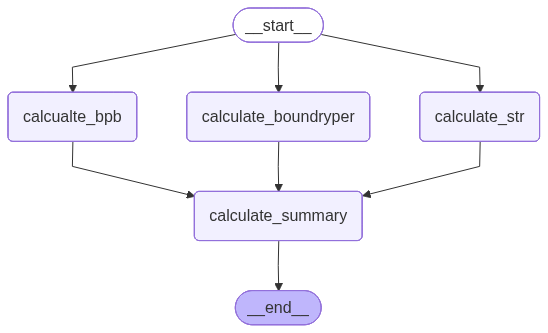

In [29]:
workflow

In [30]:
workflow.invoke({
    "runs" : 121,
    "wickets" : 1,
    "balls" : 45,
    "fours" : 4,
    "sixes" : 9
})

calculating balls per boundry
calculating boundry percentage
calculating strike rate
calculating summary


{'runs': 121,
 'wickets': 1,
 'balls': 45,
 'fours': 4,
 'sixes': 9,
 'strike_rate': 268.8888888888889,
 'balls_per_boundry': 0.6428571428571429,
 'boundry_percentage': 0.5785123966942148,
 'summary': 'Strike Rate : 268.8888888888889\n    Balls Per Boundry : 0.6428571428571429\n    Boundry Percentage : 0.5785123966942148'}